# Оценка видимости космического аппарата с точки зрения наземного наблюдателя

## О чём эта задача

Разработать программу для оценки видимости космического аппарата (КА) с точки зрения наземного наблюдателя. Программа должна определить, находится ли КА выше заданного угла возвышения над горизонтом в указанный момент времени.
Для этого нужно узнать, насколько высоко он находится над линией горизонта — это и есть угол возвышения: если угол больше порога, спутник виден

Координаты КА даны в инерциальной системе координат (ECI J2000), которая зафиксирована относительно звёзд, а Земля внутри неё вращается.  Наблюдатель стоит на Земле и вращается вместе с ней.
Чтобы связать их позиции, нужно учесть вращение Земли в момент наблюдения и корректно привести моменты времени для определения угла поворота Земли в момент наблюдения. 

## Постановка задачи

Дано:
- Координаты КА в инерциальной системе (ECI J2000)
- Момент наблюдения в шкале TT (Terrestrial Time)
- Положение наблюдателя на поверхности Земли
- Пороговый угол возвышения

Требуется:
1. Вычислить угол возвышения КА над горизонтом
2. Определить, виден ли КА (угол выше порога)
3. Вывести результат

## Исходные данные

| Параметр                  | Значение                                       |
| ------------------------- | ---------------------------------------------- |
| Координаты КА (ECI J2000) | [4435144, -2137297, 4670064] метров            |
| Момент наблюдения         | 8084.185608609847 юлианских дней от J2000 (TT) |
| Широта наблюдателя        | 45.920266° северной                            |
| Долгота наблюдателя       | -63.342286° (западная)                         |
| Порог видимости           | 15.0°                                          |


В этом ноутбуке пошагово разобран каждый этап расчёта — описана методика вычислений и приведены формулы вычислений. Все математические функции вынесены в отдельный модуль `sat_visibility.py` и покрыты тестами. 

## Входные данные

Координаты КА даны в системе ECI J2000 — инерциальной системе с началом
в центре Земли, оси которой зафиксированы относительно далёких звёзд.
Земля внутри этой системы вращается

In [4]:
import numpy as np
import math

from sat_visibility import (
    jd_tt_to_ut1,
    compute_gmst,
    eci_to_ecef,
    observer_ecef,
    ecef_to_sez,
    compute_elevation,
    is_visible,
)

# Координаты КА в инерциальной системе ECI J2000, метры
position_eci = np.array([4435144.0, -2137297.0, 4670064.0])

# Момент наблюдения: 8084.185608609847 юлианских дней от эпохи J2000 (шкала TT)
# Полная юлианская дата: JD = 2451545.0 + 8084.185608609847
jd_tt = 2451545.0 + 8084.185608609847

# Координаты наблюдателя на поверхности Земли
observer_lat = 45.920266    # северная широта, градусы
observer_lon = -63.342286   # западная долгота (отрицательная), градусы

# Порог видимости
min_elevation = 15.0         # градусы

print("Входные данные:")
print(f"  Координаты КА (ECI): {position_eci} м")
print(f"  JD (TT): {jd_tt:.6f}")
print(f"  Наблюдатель: {observer_lat}° N, {abs(observer_lon)}° W")
print(f"  Порог видимости: {min_elevation}°")

Входные данные:
  Координаты КА (ECI): [ 4435144. -2137297.  4670064.] м
  JD (TT): 2459629.185609
  Наблюдатель: 45.920266° N, 63.342286° W
  Порог видимости: 15.0°


## Какая это дата?

Первый вопрос моего исследования, хотя я ранее понимал теорию непрерывного наблюдения времени и геохроноголическую шкалу. 

Момент наблюдения задан как 8084.185608609847 юлианских дней от эпохи J2000.
Эпоха J2000 — это 12:00 UT 1 января 2000 года, что соответствует
JD = 2451545.0

Полная юлианская дата: 2451545.0 + 8084.186 = 2459629.186

Перевод в календарную дату даёт **18 февраля 2022 года, ~16:27 UTC**

Проверяем:

In [22]:
from datetime import datetime, timedelta

# J2000 начинается 1 января 2000 года, 12:00 UT
j2000 = datetime(2000, 1, 1, 12, 0, 0)

# Добавляем 8084.185608609847 дней
observation_date = j2000 + timedelta(days=8084.185608609847)

print(f"Дата наблюдения: {observation_date.strftime('%Y-%m-%d %H:%M:%S')} UTC")

Дата наблюдения: 2022-02-18 16:27:16 UTC


## Шаг 1. Временные шкалы: перевод TT → UT1

Общий подход такой, что нам необходимо привести все (наблюдателя и КА) в единую СК (систему координат) для оценки видимости КА. 

В задаче используется **ECI (Earth-Centered Inertial)** — система с началом в центре масс Земли, 
оси фиксированы и не вращаются с Землёй. Используется для описания орбиты КА, т.к. спутник движется
 по инерционной орбите без учёта вращения Земли (грубо говоря, только тогда, когда нам важна 
эквипотенциальная поверхность Земли или изучение положения КА относительно Земли, а не то, 
как она сейчас расположена относительно КА)

**ECEF (Earth-Centered Earth-Fixed)** — система с началом в центре Земли, оси вращаются вместе с Землёй
 (ось Z — вдоль полюсов, X — в плоскости пересечения экватора и 0го меридиана). 
Поверхность Земли в ECEF почти неподвижна — удобно для наблюдателя на Земле и GPS-навигаци

**Ключевое отличие** для конвертации: ECI не вращается, ECEF вращается с Землёй. 
Преобразование между ними — поворот вокруг оси Z на угол GMST (Greenwich Mean Sidereal Time) в градусах

Время дано в шкале **TT** (Terrestrial Time) — равномерной
шкале, которая используется в небесной механике и эфемеридах. Но для расчёта
вращения Земли нужно **UT1** — время, привязанное к фактическому вращению планеты

Земля вращается неравномерно (приливы, атмосферные эффекты), поэтому
TT и UT1 расходятся. Разница обозначается **ΔT = TT − UT1** и измеряется
в секундах

**Какое значение ΔT используем и почему:**

Для даты наблюдения (18 февраля 2022 года) точное значение **разницы ΔT = TT − UT1** ΔT = 69.29 в секундах
(https://www.stjarnhimlen.se/comp/time.html). 

Насколько я погрузился, то есть 
два значения ΔT для этой даты - измеренное ретроспективно и полиномиальная экстраполяция до наблюдения по Espenak-Meeus, например. 
Разница с приближенным значением (ΔT = 69.18 по Espenak-Meeus) ~0.1 с

- 0.1 с × скорость вращения Земли 7.27·10⁻⁵ рад/с ≈ 7.3·10⁻⁶ рад ≈ 1.5″
- На экваторе это ≈ 46 метров сдвига наблюдателя

Я использую ΔT напрямую
из таблиц IERS — это проще и точнее

In [ ]:
# Переводим TT в UT1
# ΔT = 69.29 сек — точное значение из таблиц IERS для февраля 2022 года
delta_t = 69.29

jd_ut1 = jd_tt_to_ut1(jd_tt, delta_t=delta_t)

print(f"JD (TT):  {jd_tt:.12f}")
print(f"JD (UT1): {jd_ut1:.12f}")
print(f"Разница:  {delta_t} секунд = {delta_t / 86400.0:.8f} дней\n")

# Оценим, на сколько градусов повернётся Земля за это время
earth_rotation_rate = 360.0 / 86164.1  # примерно градусов за секунду (звёздные сутки)
print(f"Земля поворачивается на {earth_rotation_rate * delta_t:.3f}° за {delta_t} секунд")
print("Это сопоставимо с порогом видимости, поэтому поправка важна")

JD (TT):  2459629.185608610045
JD (UT1): 2459629.184806642588
Разница:  69.29 секунд = 0.00080197 дней

Земля поворачивается на 0.289° за 69.29 секунд
Это сопоставимо с порогом видимости, поэтому поправка важна


## Шаг 2. Вычисление GMST — угла поворота Земли

**GMST** (Greenwich Mean Sidereal Time) — гринвичское среднее звёздное время.
По сути это угол, на который Земля повернулась вокруг своей оси относительно
точки весеннего равноденствия. Именно этот угол нужен для перевода координат
из инерциальной системы ECI в земную ECEF (не инерциальную)

Используем формулу IAU (IAU 1982 Resolution C1, формула Aoki et al. (1982) - 
я ее нашел по запросу рассчета времени GMST, однако, как я сейчас понимаю, 
что есть более современная формула, но расхождение на наших углах пренебрежимо 
мало):

$$\theta = 280.46061837 + 360.98564736629 \cdot (JD_{UT1} - 2451545.0)$$
$$+ 0.000387933 \cdot T^2 - \frac{T^3}{38710000}$$

где $T$ — юлианские века от эпохи J2000. Линейный член — это один оборот
за звёздные сутки (~86164 секунды), а квадратичный и кубический члены —
малые поправки на долговременные изменения скорости вращения

In [7]:
gmst_rad = compute_gmst(jd_ut1)
gmst_deg = math.degrees(gmst_rad)

print(f"GMST = {gmst_deg:.6f}°")
print(f"GMST = {gmst_rad:.8f} рад")

GMST = 35.146492°
GMST = 0.61342201 рад


## Шаг 3. Преобразование координат КА: ECI → ECEF

Теперь, зная угол поворота Земли (GMST), можно перевести координаты КА
из инерциальной системы ECI в земную ECEF

**ECEF** (Earth-Centered Earth-Fixed) — система, которая вращается вместе
с Землёй: ось Z направлена на северный полюс, ось X — в точку пересечения
экватора и гринвичского меридиана, поэтому преобрабование — поворот вокруг 
оси Z на угол GMST:

$$\begin{pmatrix} x_{ECEF} \\ y_{ECEF} \\ z_{ECEF} \end{pmatrix} =
\begin{pmatrix} \cos\theta & \sin\theta & 0 \\ -\sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{pmatrix}
\begin{pmatrix} x_{ECI} \\ y_{ECI} \\ z_{ECI} \end{pmatrix}$$

In [8]:
sat_ecef = eci_to_ecef(position_eci, gmst_rad)

print(f"КА в ECI:  {position_eci}")
print(f"КА в ECEF: {sat_ecef}")
print(f"Модуль вектора: {np.linalg.norm(sat_ecef):.0f} м")
print(f"Высота над поверхностью: {np.linalg.norm(sat_ecef) - 6371000:.0f} м (приблизительно)")

КА в ECI:  [ 4435144. -2137297.  4670064.]
КА в ECEF: [ 2396165.76201702 -4300805.78588273  4670064.        ]
Модуль вектора: 6785871 м
Высота над поверхностью: 414871 м (приблизительно)


## Шаг 4. Положение наблюдателя в ECEF (эллипсоид WGS84)

Наблюдатель задан широтой и долготой, нужны его декартовы координаты

Используем эллипсоид WGS84:
- большая полуось $a = 6\,378\,137$ м
- сжатие $f = 1/298.257$
- h = 0 наблюдтель на поверхности

```
N = a / √(1 - e² × sin²(lat))    — радиус кривизны, зависит от широты, учитываем "сплюснутость" Земли от экватора к полюсу 
x = N × cos(lat) × cos(lon)
y = N × cos(lat) × sin(lon)
z = N × (1 - e²) × sin(lat)
```

где e² = f × (2 - f) — квадрат эксцентриситета


По широте и долготе наблюдателя вычисляются его декартовы координаты
в системе ECEF

In [10]:
obs_ecef = np.array(observer_ecef(observer_lat, observer_lon))

print(f"Наблюдатель ({observer_lat}° N, {abs(observer_lon)}° W):")
print(f"  ECEF: ({obs_ecef[0]:.2f}, {obs_ecef[1]:.2f}, {obs_ecef[2]:.2f}) м")

Наблюдатель (45.920266° N, 63.342286° W):
  ECEF: (1994153.00, -3972232.55, 4559086.71) м


## Шаг 5. Вектор «наблюдатель - КА» и переход в систему SEZ

Теперь есть координаты КА и наблюдателя в одной системе (ECEF)
Вычитаем одно из другого — получаем вектор от наблюдателя к КА

Дальше переводим этот вектор в **топоцентрическую систему SEZ**:
- **S** (South) — на юг
- **E** (East) — на восток
- **Z** (Zenith) — вверх, в зенит

Компонента Z покажет, насколько КА «над горизонтом» — именно она
определяет угол возвышения

In [12]:
rel_ecef = sat_ecef - obs_ecef
sez = ecef_to_sez(rel_ecef, observer_lat, observer_lon)

print(f"Вектор «наблюдатель → КА» в ECEF: {rel_ecef}")
print(f"Вектор в SEZ (S, E, Z):")
print(f"  S (юг):      {sez[0]:.2f} м")
print(f"  E (восток):  {sez[1]:.2f} м")
print(f"  Z (зенит):   {sez[2]:.2f} м")
print(f"  Дальность:   {np.linalg.norm(sez):.2f} м")

Вектор «наблюдатель → КА» в ECEF: [ 402012.75722343 -328573.23268068  110977.28697242]
Вектор в SEZ (S, E, Z):
  S (юг):      263316.01 м
  E (восток):  211862.39 м
  Z (зенит):   409474.77 м
  Дальность:   530933.69 м


## Шаг 6. Вычисление угла возвышения

Угол возвышения ($e$) — это угол между линией горизонта и направлением
на КА. Вычисляется как арксинус отношения зенитной компоненты к полной
дальности:

$$e = \arcsin\left(\frac{Z}{|\vec{r}|}\right)$$

Если $e > 0$ — КА над горизонтом. Если $e < 0$ — под горизонтом

In [7]:
distance = np.linalg.norm(sez)
elevation_rad = math.asin(np.clip(sez[2] / distance, -1.0, 1.0))
elevation_deg = math.degrees(elevation_rad)

print(f"Угол возвышения: {elevation_deg:.4f}°")
print(f"Дальность до КА:  {distance:.2f} м ({distance / 1000:.2f} км)")

Угол возвышения: 50.4649°
Дальность до КА:  530933.69 м (530.93 км)


## Точность и ограничения подхода

В сравнении с другими найденными решениями, мое решение использует GMST — среднее звёздное время. Это стандартный подход,
но он не учитывает два эффекта:

### 1. Прецессия и нутация

Точка весеннего равноденствия, от которой отсчитывается GMST, не фиксирована —
она смещается из-за прецессии и нутации оси Земли. За 22 года с эпохи J2000
накопилось смещение ~0.3°

Более строгий подход (IAU 2000/2006) использует ERA (Earth Rotation Angle)
вместо GMST который компенсирует это смещение
Для этого нужна библиотека erfa ([ERFA/SOFA](https://pypi.org/project/pyerfa/)) — официальный астрономический стандарт

Я намеренно использую упрощённый подход с GMST, потому что:
- Достаточно для задания (ошибка ~0.3° при пороге 15°, мы ошибаемся на ~2%, 
что допустимо для быстрой гипотезы)
- Нет внешних зависимостей библиотек
- Простой алгоритм рассчета

**Эталонный расчёт через astropy даёт угол 50.22°, наш — 50.47°.**
**Разница 0.24° обусловлена именно отсутствием учёта прецессии-нутации**

## Результат

Сводим всё вместе через основную функцию `compute_elevation`,
которая выполняет все шаги автоматически, и проверяем видимость

In [13]:
elevation = compute_elevation(
    position_eci, jd_tt, observer_lat, observer_lon, delta_t=69.29
)

visible = is_visible(elevation, min_elevation=min_elevation)

status = "КА виден" if visible else "КА не виден"
print(f"Угол возвышения: {elevation:.1f} градусов, {status}")

Угол возвышения: 50.5 градусов, КА виден


## Модульные тесты
Основные функции вычисления покрыты тестами. Несколько ключевых проверок прямо в ноутбуке. 
Полный набор из 21 теста
находится в файле `test_sat_visibility.py` и запускается через `pytest`

In [28]:
# При нулевом GMST координаты ECI = ECEF (поворота нет)
assert np.allclose(eci_to_ecef([100, 200, 300], 0.0), [100, 200, 300])

# На экваторе z-координата наблюдателя = 0
x_eq, y_eq, z_eq = observer_ecef(0.0, 0.0)
assert abs(z_eq) < 0.01
assert abs(x_eq - 6378137.0) < 1.0

# Вектор в зенит даёт S = E = 0, Z > 0
s, e, z = ecef_to_sez([1, 0, 0], 0.0, 0.0)
assert abs(s) < 1e-10 and abs(e) < 1e-10 and z > 0

# is_visible работает корректно на границе
assert is_visible(15.1, min_elevation=15.0) == True
assert is_visible(14.9, min_elevation=15.0) == False

print("Все проверки прошли ✓")

Все проверки прошли ✓


## Визуализация схемы

Упрощённая схема: наблюдатель, линия горизонта, порог видимости и направление на КА

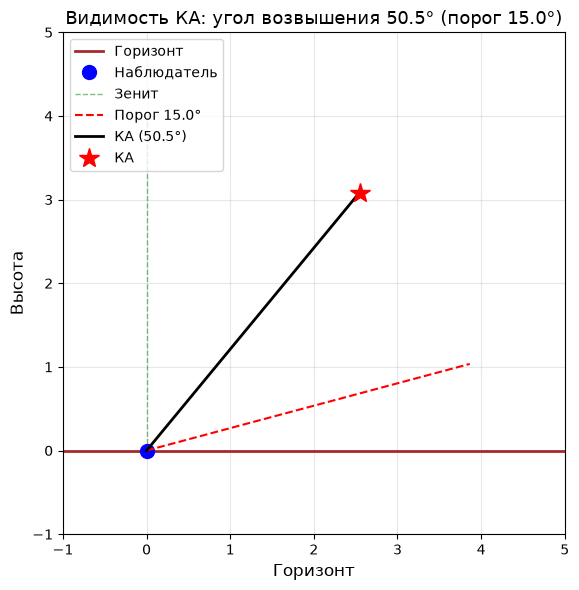

Схема сохранена в visibility_scheme.png


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.axhline(y=0, color='brown', linewidth=2, label='Горизонт')
ax.plot(0, 0, 'bo', markersize=10, label='Наблюдатель')
ax.plot([0, 0], [0, 4], 'g--', linewidth=1, alpha=0.5, label='Зенит')

angle_rad = math.radians(min_elevation)
ax.plot([0, 4 * math.cos(angle_rad)], [0, 4 * math.sin(angle_rad)],
        'r--', linewidth=1.5, label=f'Порог {min_elevation}°')

elev_rad = math.radians(elevation)
dist_plot = 4
ax.plot([0, dist_plot * math.cos(elev_rad)],
        [0, dist_plot * math.sin(elev_rad)],
        'k-', linewidth=2, label=f'КА ({elevation:.1f}°)')
ax.plot(dist_plot * math.cos(elev_rad),
        dist_plot * math.sin(elev_rad),
        'r*', markersize=15, label='КА')

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.set_xlabel('Горизонт', fontsize=12)
ax.set_ylabel('Высота', fontsize=12)
ax.set_title(f'Видимость КА: угол возвышения {elevation:.1f}° (порог {min_elevation}°)', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visibility_scheme.png', dpi=150)
plt.show()
print("Схема сохранена в visibility_scheme.png")

## Заключение

### Что мы сделали

1. **Перевели время** из шкалы TT в UT1 — учли неравномерность вращения Земли (ΔT = 69.29 сек)
2. **Вычислили GMST** — угол поворота Земли по формуле IAU
3. **Преобразовали координаты КА** из инерциальной системы ECI в земную ECEF
4. **Определили положение наблюдателя** на эллипсоиде WGS84
5. **Перешли в локальную систему SEZ** — привязку к точке наблюдения
6. **Вычислили угол возвышения** и определили видимость КА

### Файлы решения

- `sat_visibility.py` — библиотека математических функций
- `test_sat_visibility.py` — 21 модульный тест (все проходят)
- `solution.ipynb` — этот ноутбук